## This notebook exaclty implmements the RWA from Bachtold et al. 2022 and compares it to the direct integration of the SDE for x(t) 

In [ ]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------

# Physical Constants and Parameters
M = 1.0
w_0 = 10.0          # Natural frequency (rad/s)
w_p = 2*w_0*1.0      # Driving frequency (rad/s), near 2*w_0 for w_p resonance
F_p = 0.05/w_0**2      # Amplitude of the w_p driving
Q = 10.0
GAMMA= w_0/(2*Q)              # Damping coefficient
gamma = 0*10*.05*1.0              # Nonlinearity coefficient (Duffing term)

k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = 300.0             # Temperature (K)
D = GAMMA* k_B * T       # Noise strength

args = (M, w_0, w_p,GAMMA, gamma, F_p)



# Simulation Parameters
t0 = 0.0               # Start time
t1 = 100*((2*jnp.pi)/w_p)              # End time
dt0 = 0.0001
ts = jnp.linspace(t0, t1, 100000)

# Initial Conditions
x0 = -.1               # Initial displacement
v0 = 0.0               # Initial velocity
y0_x = jnp.array([x0, v0])
Q0 = x0           # Initial real amplitude
P0 = 0.0             # Initial imaginary amplitude
y0_rFrame = jnp.array([Q0, P0])


rtol=1e-6
atol=1e-6

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
def parameteric_ramp(t):
    tc = 3.0  # time when amplitude reaches ~99% of max
    ramp = 0.5 * (1 + jnp.tanh(4 * (t - tc/2) / tc))  # smooth transition from 0 to 1
    return  1

def Hamiltonian(t,Q, P, args):
    M, w_0, w_p, GAMMA, gamma, F_p = args
    dw = w_p/2 - w_0
    return 3*gamma/(16*w_p) * (Q**2 + P**2)**2 + dw/2 *(Q**2 - P**2) +  parameteric_ramp(t)*F_p/(4*M*w_p) * (P**2 - Q**2)

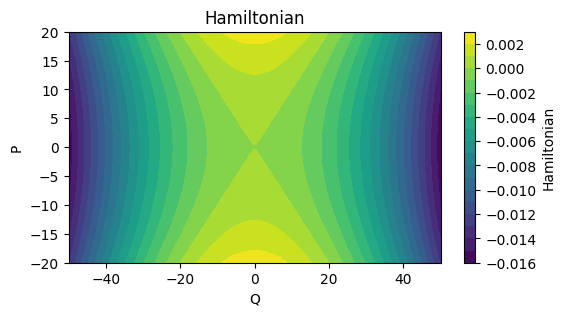

In [4]:
# Plot the Hamiltonian
Q_range = jnp.linspace(-50, 50, 100)
P_range = jnp.linspace(-20, 20, 100)
# Create meshgrid for Q and P
Q_mesh, P_mesh = jnp.meshgrid(Q_range, P_range)

# Vectorize Hamiltonian over both Q and P meshgrids
H_values = jax.vmap(lambda q, p: jax.vmap(lambda qi, pi: Hamiltonian(0.,qi, pi, args))(q, p))(Q_mesh, P_mesh)


plt.figure(figsize=(6, 3))
plt.contourf(Q_range, P_range, H_values, levels=20, cmap='viridis')
plt.colorbar(label='Hamiltonian')
plt.xlabel('Q')
plt.ylabel('P')
plt.title('Hamiltonian')
plt.show()


In [5]:
# ----------------------------
# 2. Define SDEs
# ----------------------------

# 2.1. Direct Integration SDE for x(t)
def drift_x_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    y = [x, v]
    """
    M, w_0, w_p, GAMMA, gamma, F_p = args
    x, v = state
    dxdt = v
    dvdt =  -2 * GAMMA * v - (w_0**2 - parameteric_ramp(t)*F_p/M * jnp.cos(w_p * t)) * x - gamma * x**3 
    return jnp.array([dxdt, dvdt])

def diffusion_x_fn(t, state, args):
    """
    Diffusion 
    """
    return 0*jnp.array([0.0, D])

In [6]:
# 2.2. Amplitude Equations SDEs for A_r(t) and A_i(t)
def drift_QP_fn(t, state, args):
    """
    Drift function for the amplitude equations.
    A = [A_r, A_i]
    """
    _, _, _, GAMMA, _, _ = args
    Q, P = state
        
    H = lambda _Q, _P: Hamiltonian(t,_Q, _P, args)
    
    dQdt =  jax.grad(H, 1)(Q, P) - GAMMA*Q
    dPdt = -jax.grad(H, 0)(Q, P) - GAMMA*P
    
    # Drift terms
    return jnp.array([dQdt, dPdt])

def diffusion_QP_fn(t, state, args):
    """
    Diffusion 
    """
    return 0*jnp.array([D/(M*w_0**2), D/(M*w_0**2)])


In [7]:
N = 2  # (x1, x2)
w_shape = (N,)  # state is (x1, x2, p1, p2)
brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 0.0005, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)

In [8]:

terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
# Define the time points for sampling

saveat = diffrax.SaveAt(ts=ts)


# sample 1000 points
solution_x = diffrax.diffeqsolve(
    terms_x,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_x,
    args=args,
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=10000000,
    stepsize_controller=PIDController(rtol=rtol, atol=atol),
)
sde_samples_x = solution_x.ys[:, :N]


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

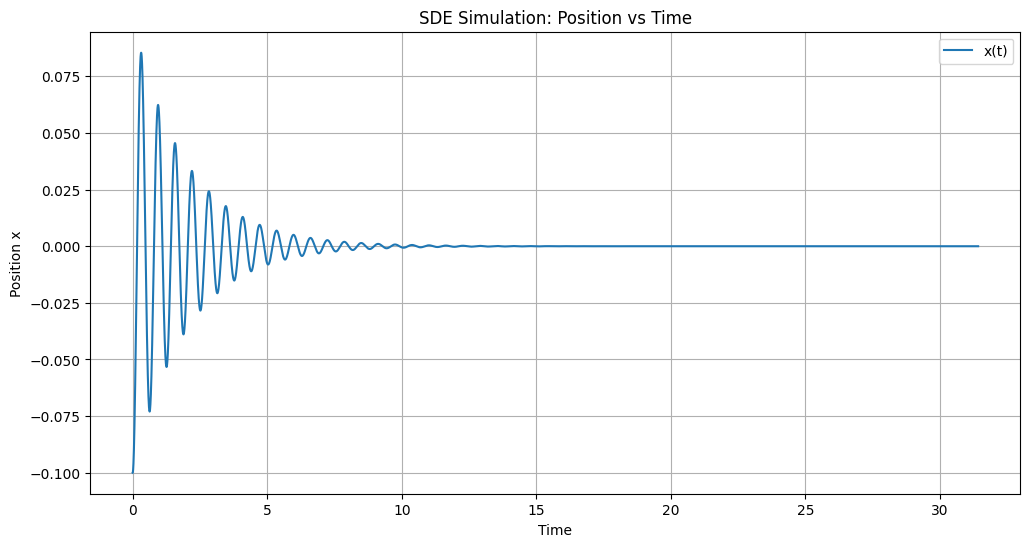

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(ts, sde_samples_x[:, 0], label='x(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

In [10]:
terms_QP = MultiTerm(ODETerm(drift_QP_fn), ControlTerm(diffusion_QP_fn, brownian_motion))

solution_QP = diffrax.diffeqsolve(
    terms_QP,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_rFrame,
    args=args,
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=10000000,
    stepsize_controller=diffrax.PIDController(rtol=rtol, atol=atol),
)
sde_samples_QP = solution_QP.ys[:, :N]



100.00%|##########| [00:00<00:00, 7271.55%/s]


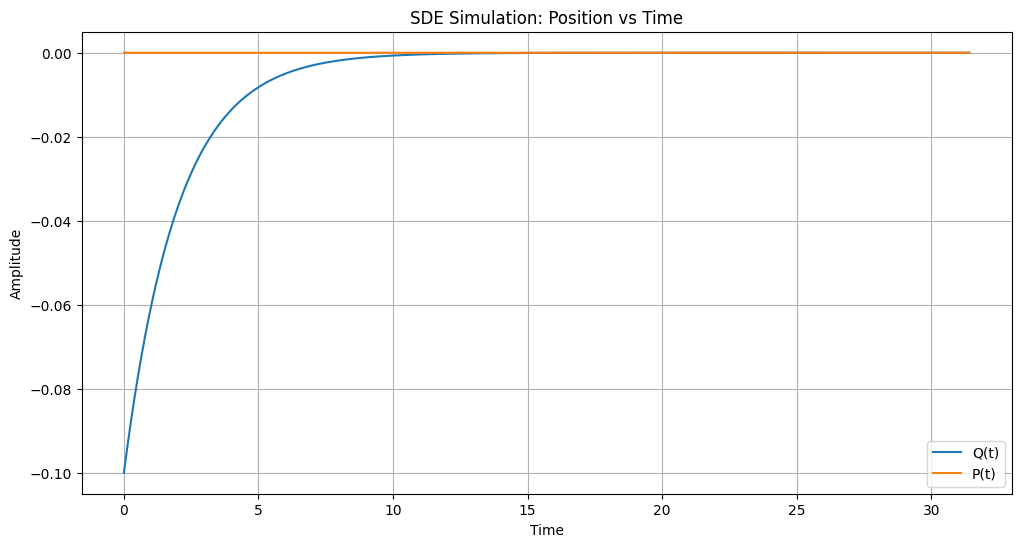

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(ts, sde_samples_QP[:, 0], label='Q(t)')
plt.plot(ts, sde_samples_QP[:, 1], label='P(t)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

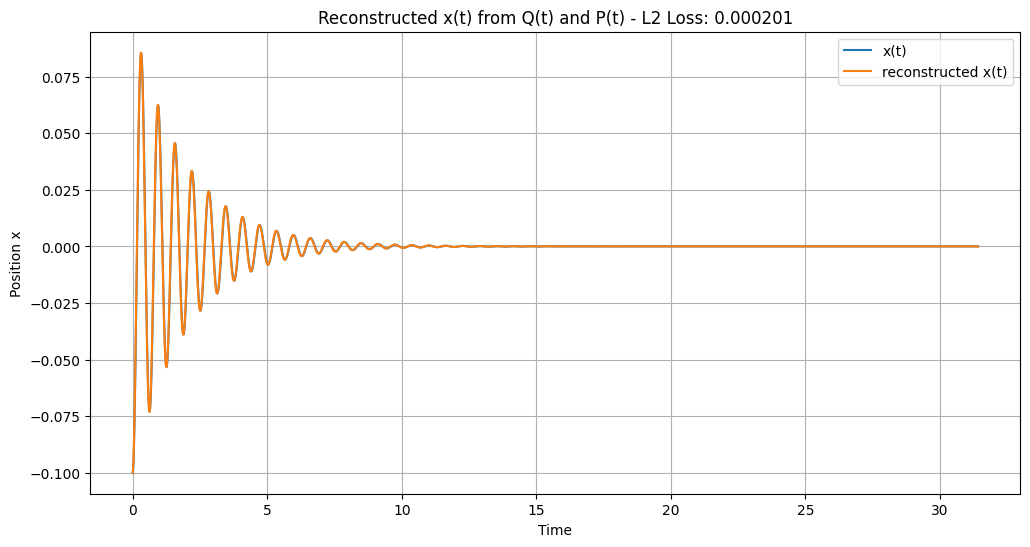

In [12]:
def reconstruct_x(t, Q, P):
    """
    Reconstruct x(t) from Q(t) and P(t).
    """
    return Q * jnp.cos(w_0 * t) + P * jnp.sin(w_0 * t)


# After the plotting code in cell [9], add:

# Compute L2 difference
l2_diff = jnp.sqrt(jnp.mean((sde_samples_x[:, 0] - reconstruct_x(ts, sde_samples_QP[:, 0], sde_samples_QP[:, 1]))**2))/jnp.linalg.norm(sde_samples_x[:, 0])

plt.figure(figsize=(12, 6))
plt.plot(ts, sde_samples_x[:, 0], label='x(t)')
plt.plot(ts, reconstruct_x(ts, sde_samples_QP[:, 0], sde_samples_QP[:, 1]), label='reconstructed x(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title(f'Reconstructed x(t) from Q(t) and P(t) - L2 Loss: {l2_diff:.6f}')
plt.grid(True)
plt.legend()

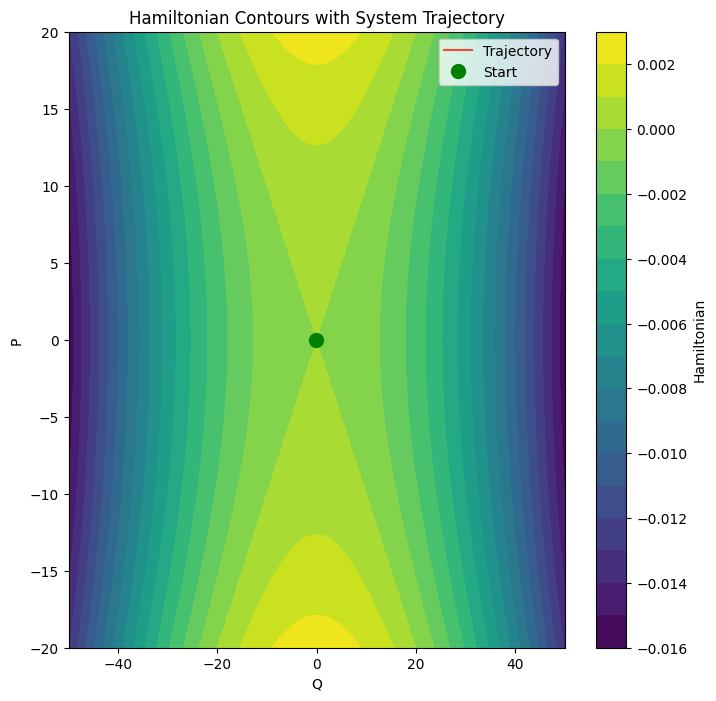

In [13]:
# Create contour plot of Hamiltonian as before
plt.figure(figsize=(8, 8))
plt.contourf(Q_range, P_range, H_values, levels=20, cmap='viridis')
plt.colorbar(label='Hamiltonian')

# Add trajectory on top
plt.plot(sde_samples_QP[:, 0], sde_samples_QP[:, 1], 'r-', label='Trajectory', alpha=0.7)
# Add starting point
plt.plot(sde_samples_QP[0, 0], sde_samples_QP[0, 1], 'go', label='Start', markersize=10)

plt.xlabel('Q')
plt.ylabel('P')
plt.title('Hamiltonian Contours with System Trajectory')
plt.legend()
plt.show()

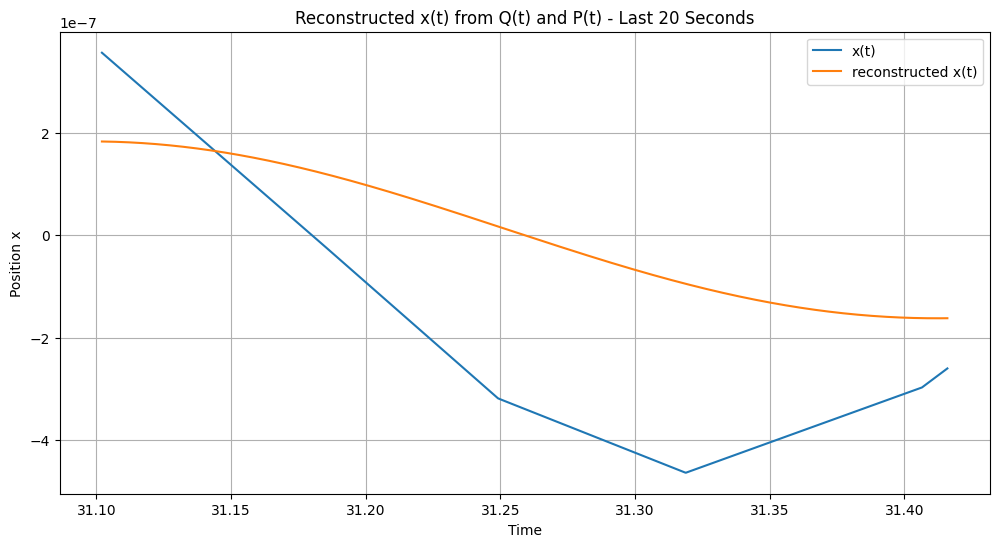

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(ts[-1000:], sde_samples_x[-1000:, 0], label='x(t)')
plt.plot(ts[-1000:], reconstruct_x(ts[-1000:], sde_samples_QP[-1000:, 0], sde_samples_QP[-1000:, 1]), label='reconstructed x(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('Reconstructed x(t) from Q(t) and P(t) - Last 20 Seconds')
plt.grid(True)
plt.legend()
plt.show()